Plotting 8 abundance regions


/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_21586/1275347810.py:26: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_21586/1275347810.py:26: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


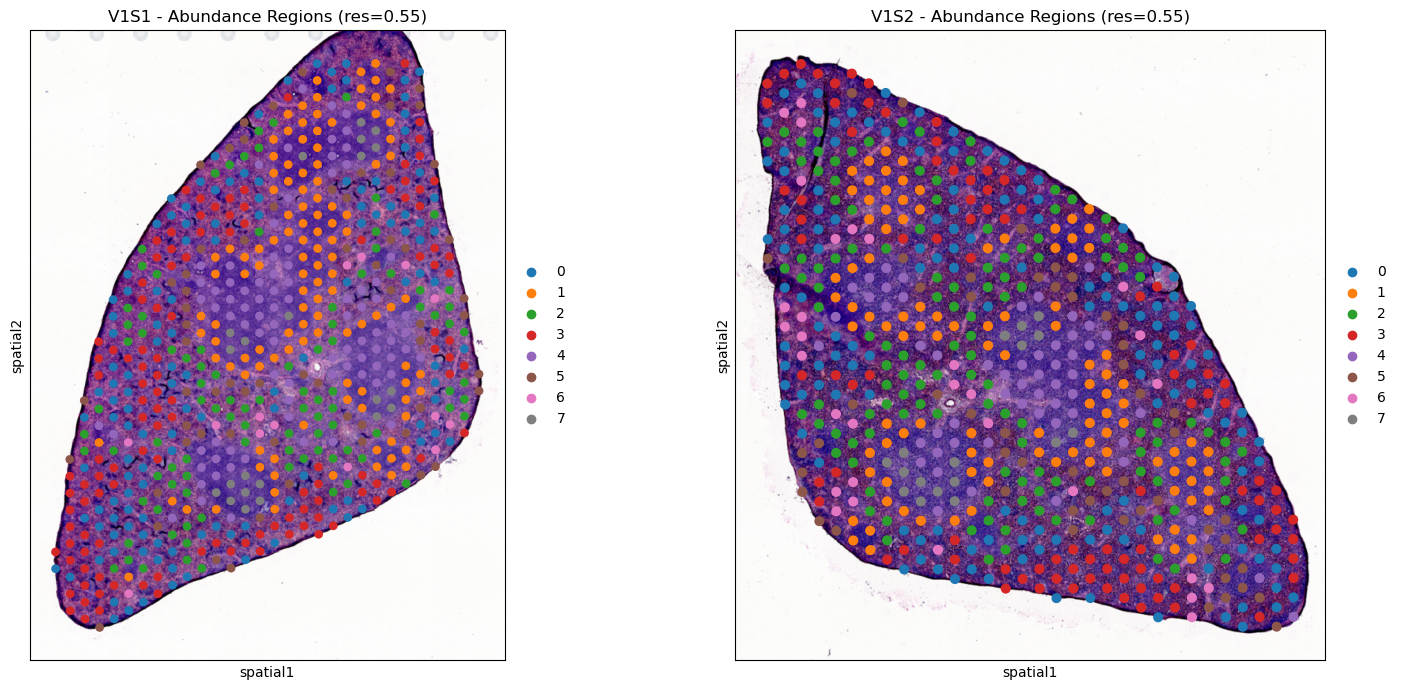

In [41]:
#!/usr/bin/env python3
"""
Spatial visualization of abundance regions (res=0.55)
"""

import scanpy as sc
import matplotlib.pyplot as plt

adata = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad')

# Compute abundance regions
sc.pp.neighbors(adata, use_rep='q05_cell_abundance_w_sf', n_neighbors=15)
sc.tl.leiden(adata, resolution=0.55, key_added='abundance_region')

print(f"Plotting {len(adata.obs['abundance_region'].unique())} abundance regions")

# Plot both samples
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, sample in enumerate(['V1S1', 'V1S2']):
    sample_mask = adata.obs['sample'] == sample
    adata_sample = adata[sample_mask]
    
    library_id = f"Spleen_Visium_Exp3A_{sample}_3wk_infected"
    
    sc.pl.spatial(
        adata_sample,
        color='abundance_region',
        library_id=library_id,
        spot_size=150,
        ax=axes[i],
        show=False,
        title=f'{sample} - Abundance Regions (res=0.55)',
        legend_loc='right margin'
    )

plt.tight_layout()
plt.savefig('abundance_regions_spatial_res055.png', dpi=300, bbox_inches='tight')
plt.show()



In [42]:
#!/usr/bin/env python3
"""
Detailed comparison of expression-based vs abundance-based clusters
"""

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print("EXPRESSION vs ABUNDANCE CLUSTERING COMPARISON")

adata = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad')

# Compute abundance regions
sc.pp.neighbors(adata, use_rep='q05_cell_abundance_w_sf', n_neighbors=15)
sc.tl.leiden(adata, resolution=0.6, key_added='abundance_region')

expression_clusters = adata.obs['paper_clusters']
abundance_regions = adata.obs['abundance_region']

# Overlap metrics
ari = adjusted_rand_score(expression_clusters, abundance_regions)
nmi = normalized_mutual_info_score(expression_clusters, abundance_regions)

print(f"\nExpression clusters: {len(expression_clusters.unique())}")
print(f"Abundance regions: {len(abundance_regions.unique())}")
print(f"\nAdjusted Rand Index: {ari:.3f}")
print(f"Normalized Mutual Information: {nmi:.3f}")

# Crosstab
crosstab = pd.crosstab(expression_clusters, abundance_regions)
print(f"\nCrosstab:")
print(crosstab)

# Dominant mappings
print("\nDominant mappings (Expression → Abundance):")
for cluster in sorted(expression_clusters.unique()):
    cluster_mask = expression_clusters == cluster
    n_total = cluster_mask.sum()
    
    region_counts = abundance_regions[cluster_mask].value_counts()
    dominant_region = region_counts.index[0]
    dominant_count = region_counts.iloc[0]
    pct = 100 * dominant_count / n_total
    
    print(f"  {cluster} → Region {dominant_region}: {dominant_count}/{n_total} ({pct:.1f}%)")

# Figure 1: Side-by-side spatial comparison
print("\nCreating spatial comparison...")
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for i, sample in enumerate(['V1S1', 'V1S2']):
    sample_mask = adata.obs['sample'] == sample
    adata_sample = adata[sample_mask]
    library_id = f"Spleen_Visium_Exp3A_{sample}_3wk_infected"
    
    # Expression clusters
    sc.pl.spatial(
        adata_sample,
        color='paper_clusters',
        library_id=library_id,
        spot_size=150,
        ax=axes[0, i],
        show=False,
        title=f'{sample} - Expression Clusters'
    )
    
    # Abundance regions
    sc.pl.spatial(
        adata_sample,
        color='abundance_region',
        library_id=library_id,
        spot_size=150,
        ax=axes[1, i],
        show=False,
        title=f'{sample} - Abundance Regions (res=0.55)'
    )

plt.tight_layout()
plt.savefig('expression_vs_abundance_spatial.png', dpi=300, bbox_inches='tight')
print("✅ Saved: expression_vs_abundance_spatial.png")
plt.close()

# Figure 2: Heatmap of crosstab (normalized by expression cluster)
print("Creating crosstab heatmap...")
crosstab_norm = crosstab.div(crosstab.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    crosstab_norm,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Fraction of spots'},
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_xlabel('Abundance Region', fontsize=12, fontweight='bold')
ax.set_ylabel('Expression Cluster', fontsize=12, fontweight='bold')
ax.set_title(f'Expression vs Abundance Overlap\nARI={ari:.3f}, NMI={nmi:.3f}', 
             fontsize=13, fontweight='bold', pad=15)

plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('expression_vs_abundance_crosstab.png', dpi=300, bbox_inches='tight')
print("✅ Saved: expression_vs_abundance_crosstab.png")
plt.close()

# Figure 3: Region composition comparison
print("Creating composition comparison...")
abundance_df = adata.obsm['q05_cell_abundance_w_sf']

# Top cell types per expression cluster
expression_composition = {}
for cluster in sorted(expression_clusters.unique()):
    mask = expression_clusters == cluster
    mean_abundance = abundance_df[mask].mean()
    expression_composition[cluster] = mean_abundance.nlargest(5)

# Top cell types per abundance region
abundance_composition = {}
for region in sorted(abundance_regions.unique()):
    mask = abundance_regions == region
    mean_abundance = abundance_df[mask].mean()
    abundance_composition[region] = mean_abundance.nlargest(5)

print("\nTop 3 cell types per Expression cluster:")
for cluster, top_types in expression_composition.items():
    print(f"  {cluster}: {', '.join([f'{ct}={val:.2f}' for ct, val in list(top_types.items())[:3]])}")

print("\nTop 3 cell types per Abundance region:")
for region, top_types in abundance_composition.items():
    print(f"  Region {region}: {', '.join([f'{ct}={val:.2f}' for ct, val in list(top_types.items())[:3]])}")

# Save mapping
mapping_df = pd.DataFrame({
    'expression_cluster': expression_clusters,
    'abundance_region': abundance_regions,
    'sample': adata.obs['sample']
})
mapping_df.to_csv('expression_abundance_mapping.csv', index=False)
print("\n✅ Saved: expression_abundance_mapping.csv")


EXPRESSION vs ABUNDANCE CLUSTERING COMPARISON

Expression clusters: 9
Abundance regions: 9

Adjusted Rand Index: 0.292
Normalized Mutual Information: 0.441

Crosstab:
abundance_region    0    1    2    3   4   5   6   7   8
paper_clusters                                          
WP-C: MZ            8    1  136   27  38  31   0   0   1
RP-A: GZMK        103   32   14    0  10  35   0   0   0
RP-E: Rhag         65  137    3    0   4  13   0   0   0
WP-B: BZ            0    0   11  113  16   1  73   0   5
RP-D: F480         45   36   25    0   0  13   0   0   0
RP-C: NGP          24   14   15    1   7  29   0   0   0
WP-A: TZ            0    0    0    7  63   0   1   0   3
RP-B: H_MK         13    3    6    0   2   6   0  45   0
WP-D: GC            0    0    0    0   0   0   0   0  33

Dominant mappings (Expression → Abundance):
  RP-A: GZMK → Region 0: 103/194 (53.1%)
  RP-B: H_MK → Region 7: 45/75 (60.0%)
  RP-C: NGP → Region 5: 29/90 (32.2%)
  RP-D: F480 → Region 0: 45/119 (37.8%)
  R

/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_21586/3309417505.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_21586/3309417505.py:72: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_21586/3309417505.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/var/folders/qb/hfnm72x95497q4_

✅ Saved: expression_vs_abundance_spatial.png
Creating crosstab heatmap...
✅ Saved: expression_vs_abundance_crosstab.png
Creating composition comparison...

Top 3 cell types per Expression cluster:
  RP-A: GZMK: Myeloid_Mac-F480=3.27, Erythrocyte_precursor=2.20, Hematopoeitic_stem_cell=1.93
  RP-B: H_MK: Myeloid_Mac-F480=2.86, Thrombocyte=2.84, Erythrocyte_precursor=1.40
  RP-C: NGP: Myeloid_Mac-F480=2.89, Erythrocyte_precursor=1.63, Hematopoeitic_stem_cell=1.60
  RP-D: F480: Myeloid_Mac-F480=4.12, Hematopoeitic_stem_cell=2.89, Erythrocyte_precursor=1.85
  RP-E: Rhag: Myeloid_Mac-F480=3.99, Hematopoeitic_stem_cell=3.92, Erythrocyte_precursor=3.82
  WP-A: TZ: Bcell_B1=1.67, Bcell_GC=0.91, CD4-Tcell_FH=0.84
  WP-B: BZ: Bcell_B1=6.39, Myeloid_Mac-F480=1.64, Bcell_naive=1.50
  WP-C: MZ: Myeloid_Mac-F480=2.77, Bcell_B1=2.00, Fibroblast_stromal=1.17
  WP-D: GC: Bcell_GC=5.49, Bcell_B1=1.57, CD8-Tcell_proliferating=0.85

Top 3 cell types per Abundance region:
  Region 0: Myeloid_Mac-F480=3.49,

Top CD8 + Myeloid per region:

Region 0:
  Myeloid_Mac-F480: r=0.254 ***
  Myeloid_Mac-B: r=0.230 ***
  Myeloid_Monocyte: r=0.217 ***

Region 1:
  Myeloid_Mac-F480: r=0.516 ***
  Myeloid_Mac-B: r=0.488 ***
  Myeloid_moDC_A: r=0.417 ***

Region 2:
  Myeloid_cDC2: r=0.404 ***
  CD8-Tcell_late-active: r=0.356 ***
  CD8-Tcell_effector: r=0.271 ***

Region 3:
  Myeloid_moDC-B: r=0.443 ***
  Myeloid_MigDC: r=0.379 ***
  Myeloid_pDC: r=0.307 ***

Region 4:
  CD8-Tcell_early-active: r=0.310 ***
  CD8-Tcell_terminal: r=0.293 ***
  CD8-Tcell_naive: r=0.285 ***

Region 5:
  Myeloid_cDC2: r=0.001 
  Myeloid_Monocyte: r=-0.002 
  Myeloid_MigDC: r=-0.085 **

Region 6:
  Myeloid_moDC-B: r=0.330 ***
  Myeloid_MigDC: r=0.322 ***
  Myeloid_pDC: r=0.220 ***

Region 7:
  Myeloid_Monocyte: r=0.052 
  Myeloid_Mac-F480: r=-0.031 
  CD8-Tcell_effector: r=-0.054 

Region 8:
  CD8-Tcell_proliferating: r=0.255 ***
  Myeloid_MigDC: r=0.212 ***
  CD8-Tcell_terminal: r=-0.009 

✅ Saved: cd8_myeloid_abundance_spearm

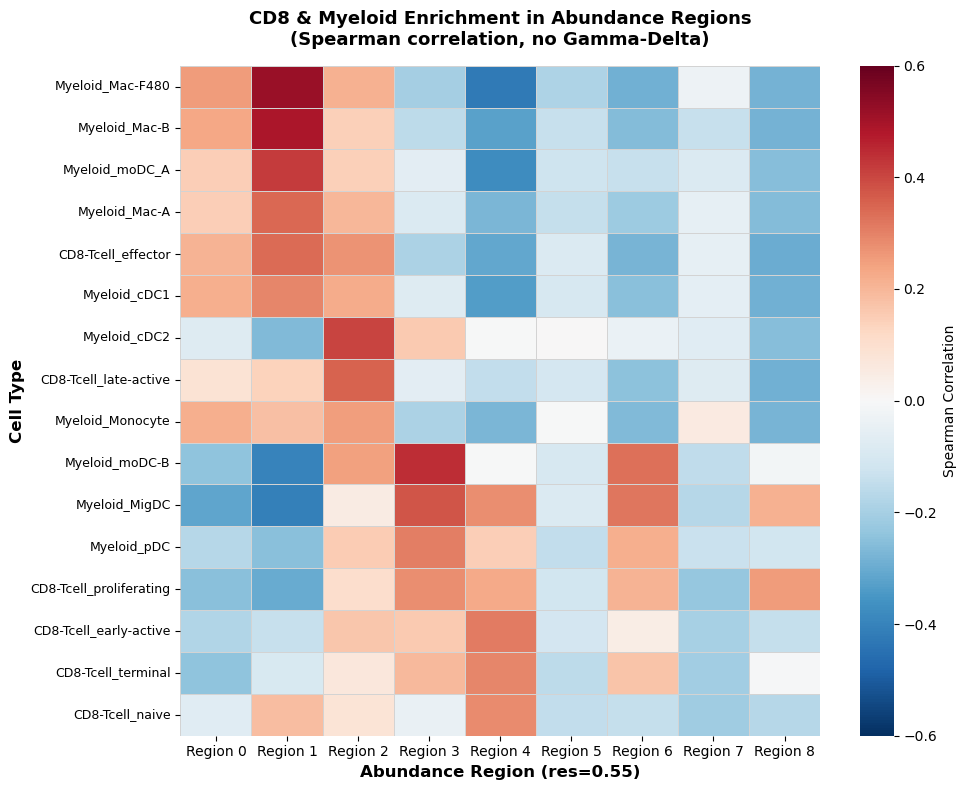

In [51]:
#!/usr/bin/env python3
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

adata = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad')

sc.pp.neighbors(adata, use_rep='q05_cell_abundance_w_sf', n_neighbors=15)
sc.tl.leiden(adata, resolution=0.6, key_added='abundance_region')

abundance_df = adata.obsm['q05_cell_abundance_w_sf']
abundance_regions = adata.obs['abundance_region']

all_cell_types = abundance_df.columns.tolist()
cd8_types = [ct for ct in all_cell_types if 'CD8' in ct and 'Gamma-Delta' not in ct]
myeloid_types = [ct for ct in all_cell_types if 'Myeloid' in ct]
cell_types = cd8_types + myeloid_types

regions = sorted(abundance_regions.unique())

correlation_matrix = np.zeros((len(cell_types), len(regions)))
pvalue_matrix = np.zeros((len(cell_types), len(regions)))

for i, cell_type in enumerate(cell_types):
    cell_abundance = abundance_df[cell_type].values
    
    for j, region in enumerate(regions):
        in_region = (abundance_regions == region).astype(int).values
        corr, pval = spearmanr(cell_abundance, in_region)
        correlation_matrix[i, j] = corr
        pvalue_matrix[i, j] = pval

corr_df = pd.DataFrame(
    correlation_matrix,
    index=cell_types,
    columns=[f"Region {r}" for r in regions]
)

pval_df = pd.DataFrame(
    pvalue_matrix,
    index=cell_types,
    columns=[f"Region {r}" for r in regions]
)

print("Top CD8 + Myeloid per region:")
for region in regions:
    col_name = f"Region {region}"
    top_cd8_myeloid = corr_df[col_name].nlargest(3)
    print(f"\nRegion {region}:")
    for cell_type, corr in top_cd8_myeloid.items():
        pval = pval_df.loc[cell_type, col_name]
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        print(f"  {cell_type}: r={corr:.3f} {sig}")

dominant_region = corr_df.idxmax(axis=1)
max_correlation = corr_df.max(axis=1)

sort_df = pd.DataFrame({
    'cell_type': cell_types,
    'dominant_region': dominant_region.values,
    'max_corr': max_correlation.values
})

sort_df['region_num'] = sort_df['dominant_region'].str.extract(r'(\d+)').astype(int)
sort_df = sort_df.sort_values(['region_num', 'max_corr'], ascending=[True, False])
corr_df_diagonal = corr_df.loc[sort_df['cell_type']]

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_df_diagonal,
    cmap='RdBu_r',
    center=0,
    vmin=-0.6,
    vmax=0.6,
    cbar_kws={'label': 'Spearman Correlation'},
    linewidths=0.5,
    linecolor='lightgray',
    ax=ax
)

ax.set_xlabel('Abundance Region (res=0.55)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cell Type', fontsize=12, fontweight='bold')
ax.set_title('CD8 & Myeloid Enrichment in Abundance Regions\n(Spearman correlation, no Gamma-Delta)', 
             fontsize=13, fontweight='bold', pad=15)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('cd8_myeloid_abundance_spearman_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: cd8_myeloid_abundance_spearman_heatmap.png")
plt.show()




✅ Saved: cd8_myeloid_abundance_log_zscore_heatmaps.png


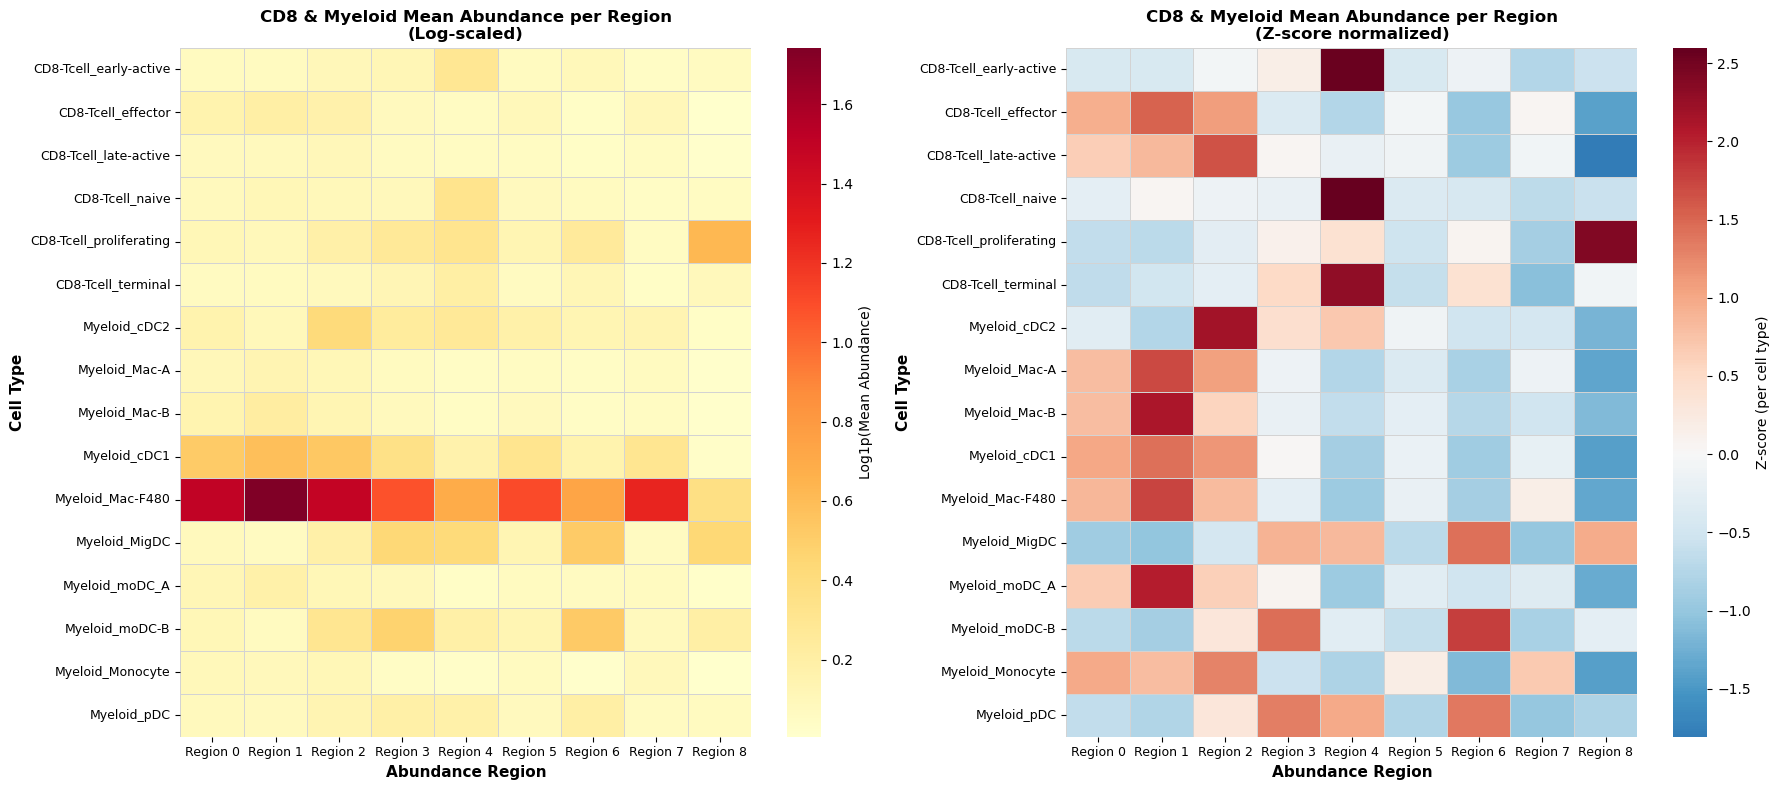

✅ Saved: cd8_myeloid_mean_abundance_per_region.csv


In [52]:
#!/usr/bin/env python3
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

adata = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad')

sc.pp.neighbors(adata, use_rep='q05_cell_abundance_w_sf', n_neighbors=15)
sc.tl.leiden(adata, resolution=0.6, key_added='abundance_region')

abundance_df = adata.obsm['q05_cell_abundance_w_sf']
abundance_regions = adata.obs['abundance_region']

all_cell_types = abundance_df.columns.tolist()
cd8_types = [ct for ct in all_cell_types if 'CD8' in ct and 'Gamma-Delta' not in ct]
myeloid_types = [ct for ct in all_cell_types if 'Myeloid' in ct]
cell_types = cd8_types + myeloid_types

regions = sorted(abundance_regions.unique())

mean_abundance = pd.DataFrame(
    index=cell_types,
    columns=[f"Region {r}" for r in regions]
)

for cell_type in cell_types:
    for region in regions:
        mask = abundance_regions == region
        mean_val = abundance_df.loc[mask, cell_type].mean()
        mean_abundance.loc[cell_type, f"Region {region}"] = mean_val

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

log_abundance = np.log1p(mean_abundance.astype(float))
sns.heatmap(
    log_abundance,
    cmap='YlOrRd',
    cbar_kws={'label': 'Log1p(Mean Abundance)'},
    linewidths=0.5,
    linecolor='lightgray',
    ax=axes[0]
)
axes[0].set_xlabel('Abundance Region', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Cell Type', fontsize=11, fontweight='bold')
axes[0].set_title('CD8 & Myeloid Mean Abundance per Region\n(Log-scaled)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

zscore_abundance = mean_abundance.astype(float).apply(lambda x: (x - x.mean()) / x.std(), axis=1)
sns.heatmap(
    zscore_abundance,
    cmap='RdBu_r',
    center=0,
    cbar_kws={'label': 'Z-score (per cell type)'},
    linewidths=0.5,
    linecolor='lightgray',
    ax=axes[1]
)
axes[1].set_xlabel('Abundance Region', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Cell Type', fontsize=11, fontweight='bold')
axes[1].set_title('CD8 & Myeloid Mean Abundance per Region\n(Z-score normalized)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0, labelsize=9)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('cd8_myeloid_abundance_log_zscore_heatmaps.png', dpi=300, bbox_inches='tight')
print("✅ Saved: cd8_myeloid_abundance_log_zscore_heatmaps.png")
plt.show()

mean_abundance.to_csv('cd8_myeloid_mean_abundance_per_region.csv')
print("✅ Saved: cd8_myeloid_mean_abundance_per_region.csv")


✅ Saved: cd8_myeloid_abundance_log_zscore_heatmaps.png


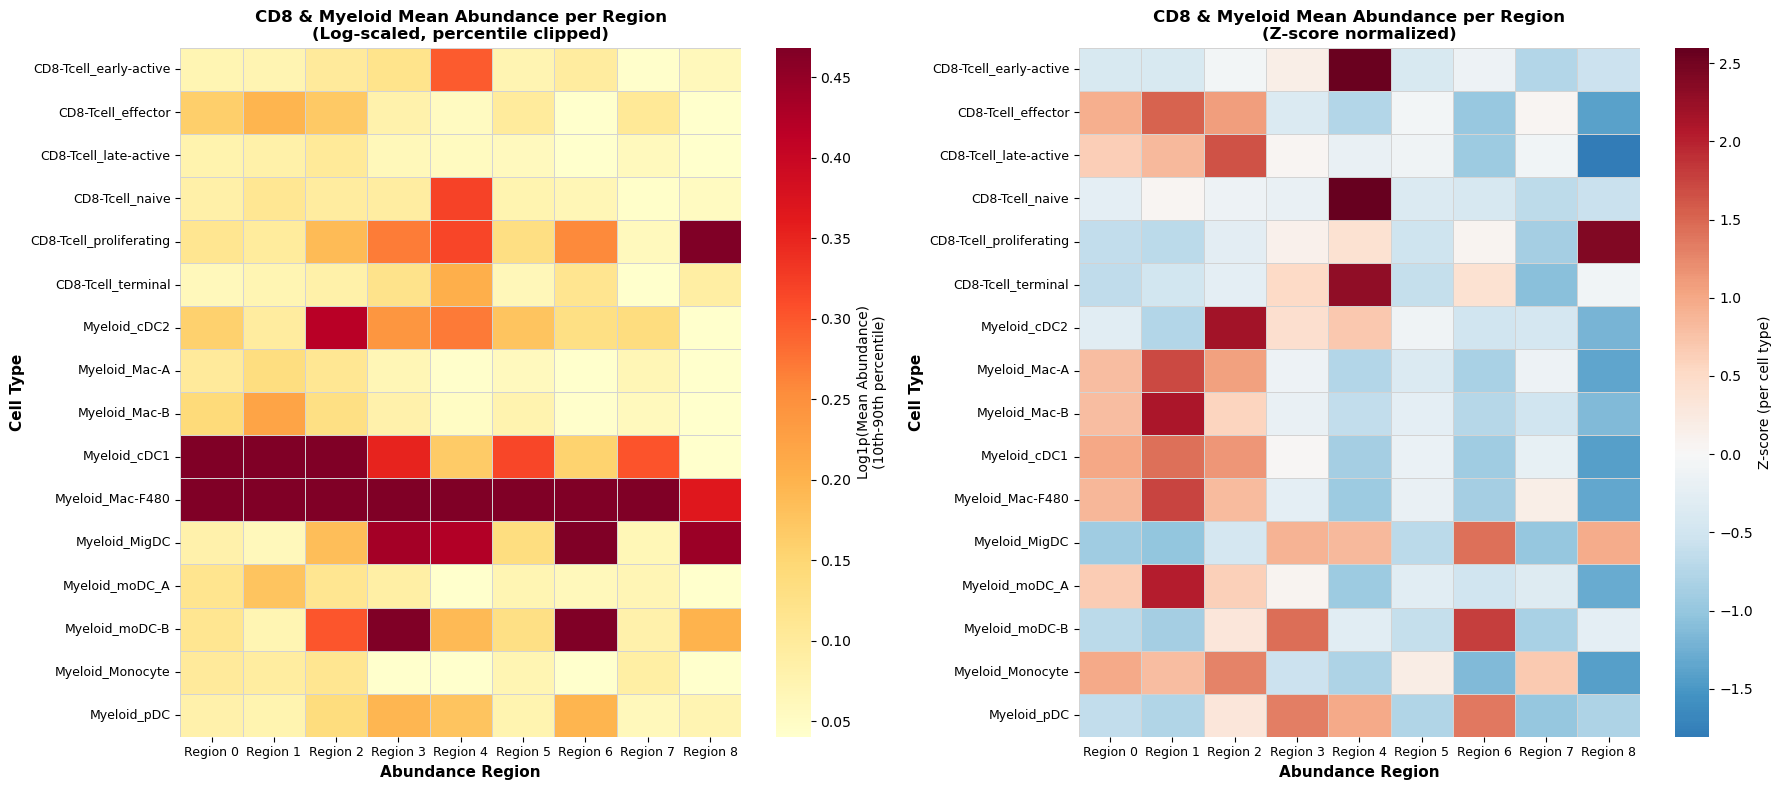

✅ Saved: cd8_myeloid_mean_abundance_per_region.csv


In [53]:
#!/usr/bin/env python3
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

adata = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad')

sc.pp.neighbors(adata, use_rep='q05_cell_abundance_w_sf', n_neighbors=15)
sc.tl.leiden(adata, resolution=0.6, key_added='abundance_region')

abundance_df = adata.obsm['q05_cell_abundance_w_sf']
abundance_regions = adata.obs['abundance_region']

all_cell_types = abundance_df.columns.tolist()
cd8_types = [ct for ct in all_cell_types if 'CD8' in ct and 'Gamma-Delta' not in ct]
myeloid_types = [ct for ct in all_cell_types if 'Myeloid' in ct]
cell_types = cd8_types + myeloid_types

regions = sorted(abundance_regions.unique())

mean_abundance = pd.DataFrame(
    index=cell_types,
    columns=[f"Region {r}" for r in regions]
)

for cell_type in cell_types:
    for region in regions:
        mask = abundance_regions == region
        mean_val = abundance_df.loc[mask, cell_type].mean()
        mean_abundance.loc[cell_type, f"Region {region}"] = mean_val

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

log_abundance = np.log1p(mean_abundance.astype(float))

vmin = np.percentile(log_abundance.values, 10)
vmax = np.percentile(log_abundance.values, 90)

sns.heatmap(
    log_abundance,
    cmap='YlOrRd',
    vmin=vmin,
    vmax=vmax,
    cbar_kws={'label': 'Log1p(Mean Abundance)\n(10th-90th percentile)'},
    linewidths=0.5,
    linecolor='lightgray',
    ax=axes[0]
)
axes[0].set_xlabel('Abundance Region', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Cell Type', fontsize=11, fontweight='bold')
axes[0].set_title('CD8 & Myeloid Mean Abundance per Region\n(Log-scaled, percentile clipped)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

zscore_abundance = mean_abundance.astype(float).apply(lambda x: (x - x.mean()) / x.std(), axis=1)
sns.heatmap(
    zscore_abundance,
    cmap='RdBu_r',
    center=0,
    cbar_kws={'label': 'Z-score (per cell type)'},
    linewidths=0.5,
    linecolor='lightgray',
    ax=axes[1]
)
axes[1].set_xlabel('Abundance Region', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Cell Type', fontsize=11, fontweight='bold')
axes[1].set_title('CD8 & Myeloid Mean Abundance per Region\n(Z-score normalized)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0, labelsize=9)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('cd8_myeloid_abundance_log_zscore_heatmaps.png', dpi=300, bbox_inches='tight')
print("✅ Saved: cd8_myeloid_abundance_log_zscore_heatmaps.png")
plt.show()

mean_abundance.to_csv('cd8_myeloid_mean_abundance_per_region.csv')
print("✅ Saved: cd8_myeloid_mean_abundance_per_region.csv")




CELL TYPE × ABUNDANCE REGION CORRELATION

Top 5 cell types per region:

Region 0:
  Erythrocyte: r=0.334 ***
  Myeloid_Mac-F480: r=0.209 ***
  Bcell_plasma: r=0.206 ***
  Erythrocyte_precursor: r=0.172 ***
  Myeloid_cDC1: r=0.165 ***

Region 1:
  Hematopoeitic_stem_cell: r=0.784 ***
  Erythrocyte_precursor: r=0.711 ***
  Myeloid_Mac-F480: r=0.540 ***
  Myeloid_Mac-B: r=0.511 ***
  Erythrocyte: r=0.483 ***

Region 2:
  Endothelial: r=0.416 ***
  Myeloid_cDC2: r=0.353 ***
  CD8-Tcell_late-active: r=0.336 ***
  CD4-Tcell_TH1: r=0.286 ***
  CD4-Tcell_cytotoxic: r=0.222 ***

Region 3:
  Bcell_B1: r=0.501 ***
  Bcell_memory: r=0.418 ***
  Myeloid_moDC-B: r=0.416 ***
  Bcell_naive: r=0.348 ***
  Myeloid_MigDC: r=0.324 ***

Region 4:
  CD4-Tcell_FH: r=0.539 ***
  CD8-Tcell_naive: r=0.496 ***
  CD8-Tcell_early-active: r=0.468 ***
  CD8-Tcell_terminal: r=0.451 ***
  CD4-Tcell_naive: r=0.410 ***

Region 5:
  Neutrophil_Elane: r=0.224 ***
  Neutrophil: r=0.156 ***
  Fibroblast_mesothelial: r=0.02

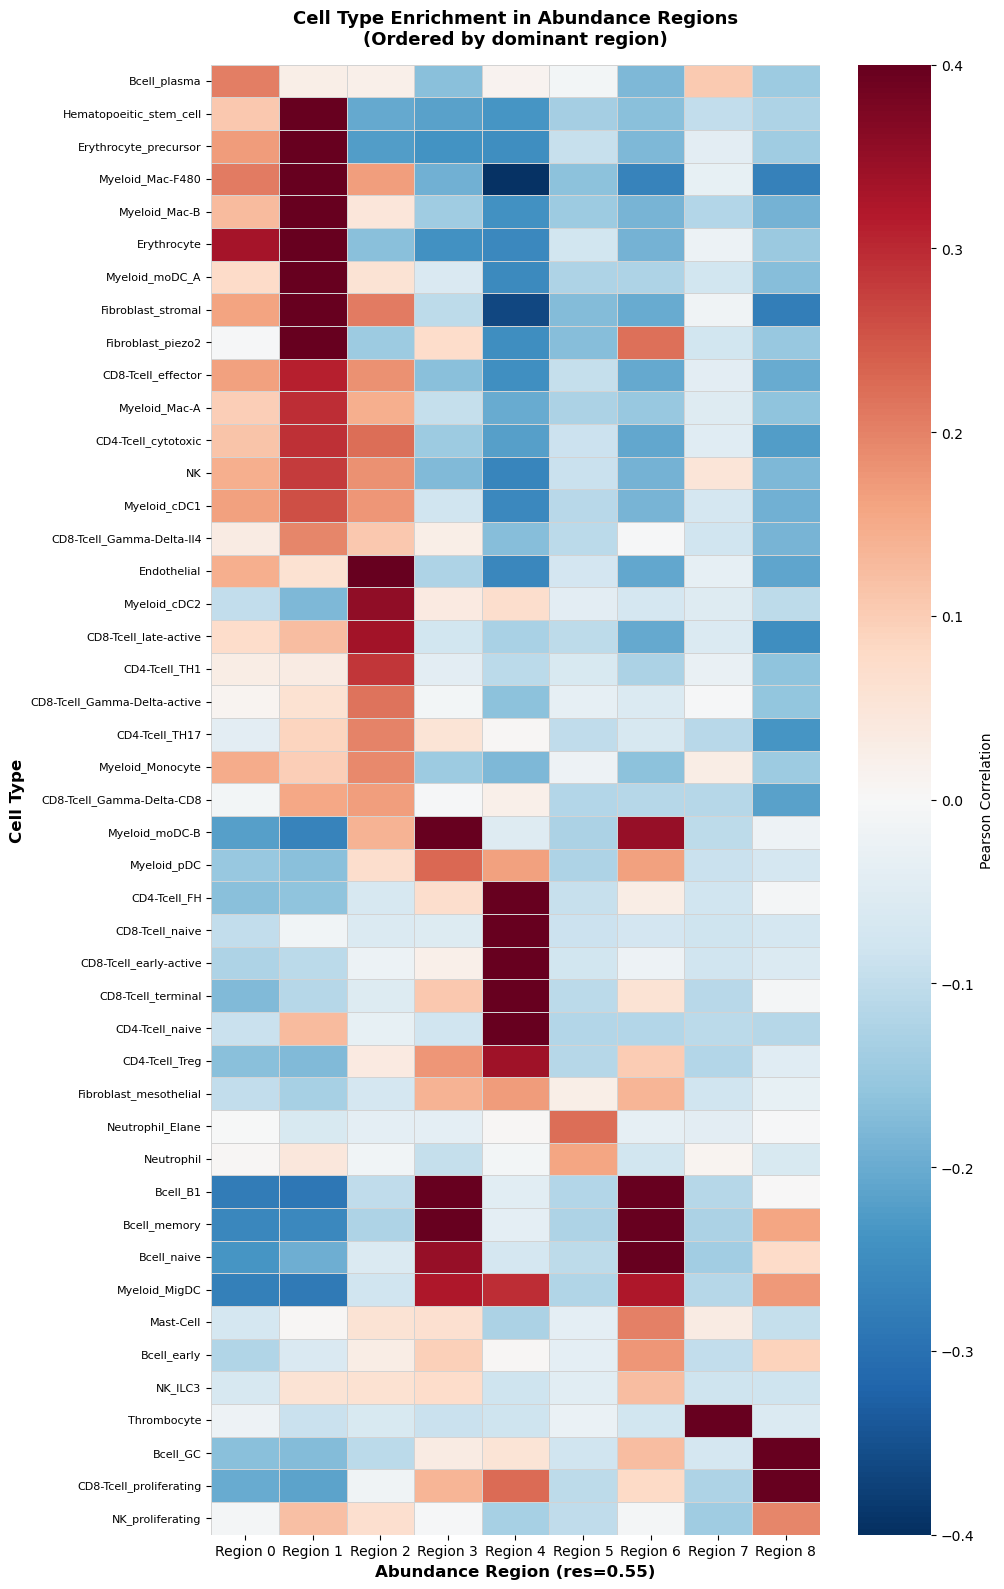

✅ Saved CSV files


In [30]:
# ============================================================
# Cell Type × Abundance Region Correlation Heatmap
# ============================================================
from scipy.stats import pearsonr

print("\n" + "="*80)
print("CELL TYPE × ABUNDANCE REGION CORRELATION")
print("="*80)

# Get abundance data (already loaded above)
cell_types = abundance_df.columns.tolist()
regions = sorted(abundance_regions.unique())

# Compute correlations
correlation_matrix = np.zeros((len(cell_types), len(regions)))
pvalue_matrix = np.zeros((len(cell_types), len(regions)))

for i, cell_type in enumerate(cell_types):
    cell_abundance = abundance_df[cell_type].values
    
    for j, region in enumerate(regions):
        in_region = (abundance_regions == region).astype(int).values
        corr, pval = pearsonr(cell_abundance, in_region)
        correlation_matrix[i, j] = corr
        pvalue_matrix[i, j] = pval

corr_df = pd.DataFrame(
    correlation_matrix,
    index=cell_types,
    columns=[f"Region {r}" for r in regions]
)

pval_df = pd.DataFrame(
    pvalue_matrix,
    index=cell_types,
    columns=[f"Region {r}" for r in regions]
)

# Top cell types per region
print("\nTop 5 cell types per region:")
for region in regions:
    col_name = f"Region {region}"
    top5 = corr_df[col_name].nlargest(5)
    print(f"\nRegion {region}:")
    for cell_type, corr in top5.items():
        pval = pval_df.loc[cell_type, col_name]
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        print(f"  {cell_type}: r={corr:.3f} {sig}")

# Heatmap with diagonal ordering (cell types ordered by dominant region)
dominant_region = corr_df.idxmax(axis=1)
max_correlation = corr_df.max(axis=1)

sort_df = pd.DataFrame({
    'cell_type': cell_types,
    'dominant_region': dominant_region.values,
    'max_corr': max_correlation.values
})

sort_df['region_num'] = sort_df['dominant_region'].str.extract(r'(\d+)').astype(int)
sort_df = sort_df.sort_values(['region_num', 'max_corr'], ascending=[True, False])

corr_df_diagonal = corr_df.loc[sort_df['cell_type']]

fig, ax = plt.subplots(figsize=(10, 16))

sns.heatmap(
    corr_df_diagonal,
    cmap='RdBu_r',
    center=0,
    vmin=-0.4,
    vmax=0.4,
    cbar_kws={'label': 'Pearson Correlation'},
    linewidths=0.5,
    linecolor='lightgray',
    ax=ax
)

ax.set_xlabel('Abundance Region (res=0.55)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cell Type', fontsize=12, fontweight='bold')
ax.set_title('Cell Type Enrichment in Abundance Regions\n(Ordered by dominant region)', 
             fontsize=13, fontweight='bold', pad=15)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('celltype_abundance_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: celltype_abundance_correlation_heatmap.png")
plt.show()

# Save correlation data
corr_df.to_csv('celltype_abundance_correlations.csv')
pval_df.to_csv('celltype_abundance_pvalues.csv')
print("✅ Saved CSV files")

In [17]:
#!/usr/bin/env python3
"""
Cell2location NMF co-localization analysis
Identifies spatial co-occurrence of cell types for cellular interaction prediction
"""

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cell2location import run_colocation

print("="*80)
print("CELL2LOCATION NMF CO-LOCALIZATION ANALYSIS")
print("="*80)

# Load infected data
adata = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad')

print(f"\nData: {adata.shape[0]} spots, {adata.shape[1]} genes")
print(f"Samples: {adata.obs['sample'].unique()}")

# Verify required columns
if 'sample' not in adata.obs.columns:
    raise KeyError("'sample' column not found in adata.obs")

print("\nCell type abundance matrices available:")
for key in adata.obsm.keys():
    if 'abundance' in key:
        print(f"  - {key}")

print("\n" + "="*80)
print("Running NMF with factors 15-30")
print("This will take several minutes...")
print("="*80)

res_dict, adata_nmf = run_colocation(
    adata,
    model_name='CoLocatedGroupsSklearnNMF',
    train_args={
        'n_fact': np.arange(15, 31),
        'sample_name_col': 'sample',
        'n_restarts': 3
    },
    model_kwargs={
        'alpha': 0.0001,
        'init': 'random',
        'nmf_kwd_args': {'tol': 0.000001, 'max_iter': 1000}
    },
    export_args={'path': 'nmf_colocation_results/'}
)

print("\n" + "="*80)
print("NMF ANALYSIS COMPLETE")
print("="*80)

print("\nResults saved to: nmf_colocation_results/")

print("\n" + "="*80)
print("FACTOR CHARACTERIZATION SUMMARY")
print("="*80)

summary_data = []

for n_fact in range(15, 31):
    if f'n_fact{n_fact}' not in res_dict:
        continue
        
    mod = res_dict[f'n_fact{n_fact}']['mod']
    
    # Get factor loadings (cell types × factors)
    loadings = mod.samples['post_sample_means']['cell_type_factors']
    cell_type_names = adata.obsm['q05_cell_abundance_w_sf'].columns.tolist()
    
    if loadings.shape[0] != len(cell_type_names):
        cell_type_names = cell_type_names[:loadings.shape[0]]
    
    loadings_df = pd.DataFrame(
        loadings,
        index=cell_type_names,
        columns=[f'Factor_{i}' for i in range(loadings.shape[1])]
    )
    
    # For each factor, get top 3 cell types
    for i in range(loadings_df.shape[1]):
        factor_col = f'Factor_{i}'
        top3 = loadings_df[factor_col].nlargest(3)
        
        # Format: "Bcell_GC (0.85), Bcell_B1 (0.45), CD4_FH (0.32)"
        top3_str = ", ".join([f"{ct} ({wt:.2f})" for ct, wt in top3.items()])
        
        summary_data.append({
            'n_factors': n_fact,
            'factor_id': i,
            'top_3_celltypes': top3_str,
            'max_weight': top3.iloc[0]
        })

summary_df = pd.DataFrame(summary_data)

for n_fact in range(15, 31):
    if f'n_fact{n_fact}' not in res_dict:
        continue
    
    print(f"\n{'='*70}")
    print(f"N_FACTORS = {n_fact}")
    print(f"{'='*70}")
    
    sub_df = summary_df[summary_df['n_factors'] == n_fact]
    for _, row in sub_df.iterrows():
        print(f"Factor {row['factor_id']:2d}: {row['top_3_celltypes']}")

summary_df.to_csv('nmf_factor_summary.csv', index=False)
print(f"\n✅ Saved: nmf_factor_summary.csv")

print("\n" + "="*80)
print("GENERATING MULTI-PANEL COMPARISON")
print("="*80)

key_factors = [15, 18, 22, 26, 30]
available_factors = [n for n in key_factors if f'n_fact{n}' in res_dict]

if len(available_factors) >= 2:
    fig, axes = plt.subplots(1, len(available_factors), figsize=(6*len(available_factors), 10))
    if len(available_factors) == 1:
        axes = [axes]
    
    for idx, n_fact in enumerate(available_factors):
        mod = res_dict[f'n_fact{n_fact}']['mod']
        
        # Get loadings
        loadings = mod.samples['post_sample_means']['cell_type_factors']
        cell_type_names = adata.obsm['q05_cell_abundance_w_sf'].columns.tolist()
        if loadings.shape[0] != len(cell_type_names):
            cell_type_names = cell_type_names[:loadings.shape[0]]
        
        loadings_df = pd.DataFrame(
            loadings,
            index=cell_type_names,
            columns=[f'F{i}' for i in range(loadings.shape[1])]
        )
        
        # Normalize across factors for each cell type (show relative enrichment)
        loadings_norm = loadings_df.div(loadings_df.max(axis=1), axis=0)
        
        # Plot
        import seaborn as sns
        sns.heatmap(
            loadings_norm,
            cmap='YlOrRd',
            vmin=0,
            vmax=1,
            cbar_kws={'label': 'Relative weight'},
            ax=axes[idx],
            yticklabels=True if idx == 0 else False,
            xticklabels=True
        )
        axes[idx].set_title(f'{n_fact} Factors', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Factor', fontsize=11)
        if idx == 0:
            axes[idx].set_ylabel('Cell Type', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('nmf_multipanel_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: nmf_multipanel_comparison.png")
else:
    print("⚠️ Not enough factors available for multi-panel plot")

SELECTED_N = 22

if f'n_fact{SELECTED_N}' in res_dict:
    print("\n" + "="*80)
    print(f"CD8-MYELOID CO-LOCALIZATION: {SELECTED_N} FACTORS")
    print("="*80)
    
    mod = res_dict[f'n_fact{SELECTED_N}']['mod']
    loadings = mod.samples['post_sample_means']['cell_type_factors']
    cell_type_names = adata.obsm['q05_cell_abundance_w_sf'].columns.tolist()
    
    if loadings.shape[0] != len(cell_type_names):
        cell_type_names = cell_type_names[:loadings.shape[0]]
    
    loadings_df = pd.DataFrame(
        loadings,
        index=cell_type_names,
        columns=[f'Factor_{i}' for i in range(loadings.shape[1])]
    )
    
    cd8_types = [ct for ct in loadings_df.index if 'CD8' in ct]
    myeloid_types = [ct for ct in loadings_df.index if 'Myeloid' in ct]
    
    for i in range(loadings_df.shape[1]):
        factor_col = f'Factor_{i}'
        max_cd8 = loadings_df.loc[cd8_types, factor_col].max() if cd8_types else 0
        max_myeloid = loadings_df.loc[myeloid_types, factor_col].max() if myeloid_types else 0
        
        if max_cd8 > 0.3 and max_myeloid > 0.3:
            print(f"\n🎯 Factor {i}:")
            top10 = loadings_df[factor_col].nlargest(10)
            for cell_type, weight in top10.items():
                print(f"   {cell_type}: {weight:.3f}")




CELL2LOCATION NMF CO-LOCALIZATION ANALYSIS

Data: 1268 spots, 5155 genes
Samples: ['V1S2', 'V1S1']
Categories (2, object): ['V1S1', 'V1S2']

Cell type abundance matrices available:
  - means_cell_abundance_w_sf
  - q05_cell_abundance_w_sf
  - q95_cell_abundance_w_sf
  - stds_cell_abundance_w_sf

Running NMF with factors 15-30
This will take several minutes...
### Analysis name: CoLocatedGroupsSklearnNMF_15combinations_1268locations_45factors


/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/cell2location/run_colocation.py:384: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/cell2location/run_colocation.py:384: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


### Analysis name: CoLocatedGroupsSklearnNMF_16combinations_1268locations_45factors


/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/cell2location/run_colocation.py:384: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


...

### Analysis name: CoLocatedGroupsSklearnNMF_20combinations_1268locations_45factors


/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/cell2location/run_colocation.py:384: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


/opt/anaconda3/envs/hd_visium_env/lib/python3.10/site-packages/cell2location/run_colocation.py:384: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


### Analysis name: CoLocatedGroupsSklearnNMF_21combinations_1268locations_45factors


KeyboardInterrupt: 

Data: 1268 spots, 5155 genes

Raw range: 0.000 to 14.861
Log1p range: 0.000 to 2.764

Found 9 abundance regions

Region 0: 237 spots (18.7%)
  Hematopoeitic_stem_cell: 5.03
  Myeloid_Mac-F480: 4.61
  Erythrocyte_precursor: 4.32
  Erythrocyte: 2.52
  Fibroblast_stromal: 1.67

Region 1: 221 spots (17.4%)
  Myeloid_Mac-F480: 2.52
  Erythrocyte_precursor: 1.60
  Bcell_B1: 1.03
  Erythrocyte: 1.02
  Fibroblast_stromal: 1.01

Region 2: 205 spots (16.2%)
  Myeloid_Mac-F480: 3.87
  Erythrocyte: 2.30
  Hematopoeitic_stem_cell: 2.04
  Erythrocyte_precursor: 1.62
  Fibroblast_stromal: 1.50

Region 3: 155 spots (12.2%)
  Myeloid_Mac-F480: 2.96
  Bcell_B1: 1.81
  Fibroblast_stromal: 1.26
  Endothelial: 1.15
  Bcell_naive: 0.68

Region 4: 146 spots (11.5%)
  Bcell_B1: 5.89
  Myeloid_Mac-F480: 2.23
  Bcell_naive: 1.14
  Fibroblast_stromal: 1.10
  Endothelial: 0.75

Region 5: 108 spots (8.5%)
  Bcell_B1: 1.19
  Bcell_plasma: 0.85
  Myeloid_Mac-F480: 0.84
  Bcell_GC: 0.64
  Myeloid_MigDC: 0.59

Region 

/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_21586/3727955572.py:75: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sample, color='abundance_regions', library_id=lib_id,


✅ Saved: abundance_log1p_spatial_V1S1.png


/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_21586/3727955572.py:75: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sample, color='abundance_regions', library_id=lib_id,


✅ Saved: abundance_log1p_spatial_V1S2.png

Top 5 cell types per region:

Region 0:
  Hematopoeitic_stem_cell: r=0.784 ***
  Erythrocyte_precursor: r=0.703 ***
  Myeloid_Mac-F480: r=0.529 ***
  Myeloid_Mac-B: r=0.503 ***
  Erythrocyte: r=0.461 ***

Region 1:
  Neutrophil_Elane: r=0.227 ***
  Bcell_plasma: r=0.221 ***
  Neutrophil: r=0.196 ***
  Endothelial: r=0.030 
  Erythrocyte_precursor: r=0.017 

Region 2:
  Erythrocyte: r=0.353 ***
  Myeloid_cDC1: r=0.290 ***
  Myeloid_Mac-F480: r=0.286 ***
  Fibroblast_stromal: r=0.252 ***
  Endothelial: r=0.231 ***

Region 3:
  Myeloid_cDC2: r=0.416 ***
  Endothelial: r=0.236 ***
  CD8-Tcell_Gamma-Delta-active: r=0.189 ***
  CD8-Tcell_late-active: r=0.175 ***
  CD4-Tcell_TH1: r=0.171 ***

Region 4:
  Bcell_B1: r=0.571 ***
  Myeloid_moDC-B: r=0.522 ***
  Bcell_memory: r=0.401 ***
  Bcell_naive: r=0.296 ***
  Myeloid_MigDC: r=0.236 ***

Region 5:
  CD4-Tcell_FH: r=0.581 ***
  CD8-Tcell_naive: r=0.567 ***
  CD8-Tcell_early-active: r=0.532 ***
  CD8-

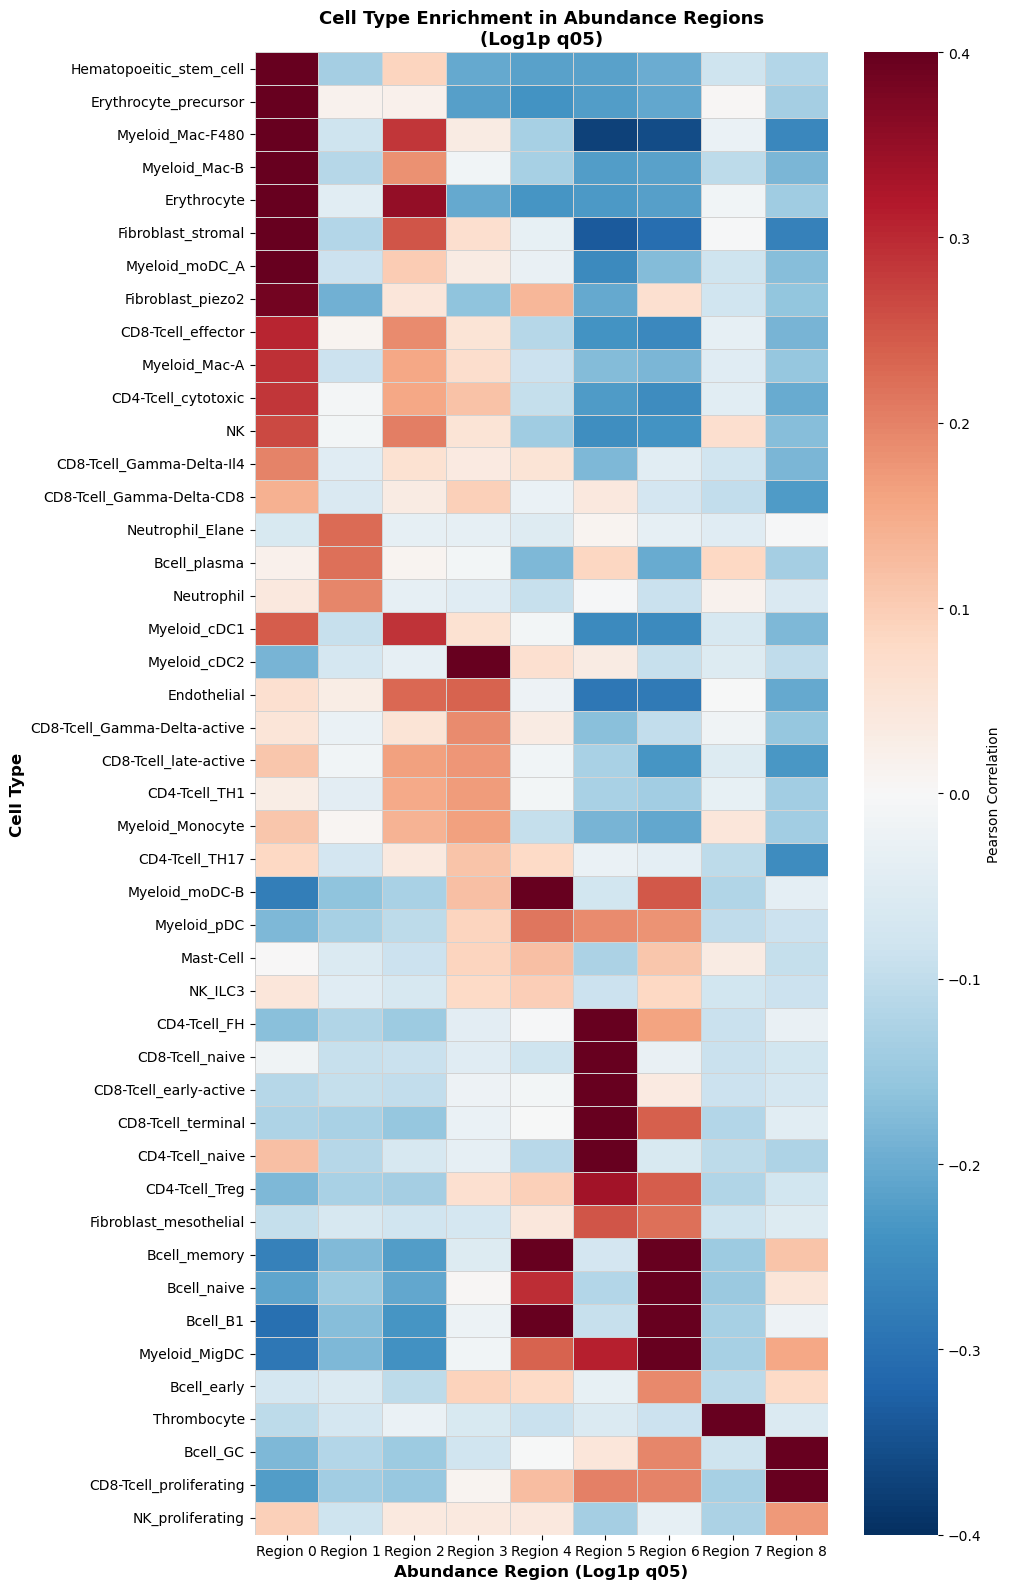

✅ Saved CSV files


In [58]:
#!/usr/bin/env python3
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

adata = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad')

print(f"Data: {adata.shape[0]} spots, {adata.shape[1]} genes")

abundance_raw = adata.obsm['q05_cell_abundance_w_sf'].copy()
abundance_log = np.log1p(abundance_raw)

print(f"\nRaw range: {abundance_raw.values.min():.3f} to {abundance_raw.values.max():.3f}")
print(f"Log1p range: {abundance_log.values.min():.3f} to {abundance_log.values.max():.3f}")

adata_abund = sc.AnnData(
    X=abundance_log.values,
    obs=adata.obs.copy(),
    var=pd.DataFrame(index=abundance_log.columns)
)
adata_abund.obsm['spatial'] = adata.obsm['spatial'].copy()
adata_abund.uns['spatial'] = adata.uns['spatial'].copy()

sc.pp.neighbors(adata_abund, n_neighbors=15, random_state=42)
sc.tl.leiden(adata_abund, resolution=0.65, random_state=42, key_added='abundance_regions')

n_regions = adata_abund.obs['abundance_regions'].nunique()
print(f"\nFound {n_regions} abundance regions")

for region in sorted(adata_abund.obs['abundance_regions'].unique()):
    mask = adata_abund.obs['abundance_regions'] == region
    n_spots = mask.sum()
    pct = 100 * n_spots / len(adata_abund)
    
    region_abund = abundance_raw[mask].mean(axis=0)
    top5 = region_abund.nlargest(5)
    
    print(f"\nRegion {region}: {n_spots} spots ({pct:.1f}%)")
    for ct, val in top5.items():
        print(f"  {ct}: {val:.2f}")

if 'paper_clusters' in adata.obs.columns:
    expr_clusters = adata.obs['paper_clusters'].values
    abund_regions = adata_abund.obs['abundance_regions'].values
    
    ari = adjusted_rand_score(expr_clusters, abund_regions)
    nmi = normalized_mutual_info_score(expr_clusters, abund_regions)
    
    print(f"\nAdjusted Rand Index: {ari:.3f}")
    print(f"Normalized Mutual Information: {nmi:.3f}")
    
    crosstab = pd.crosstab(adata.obs['paper_clusters'], adata_abund.obs['abundance_regions'])
    print("\nCrosstab:")
    print(crosstab)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
    ax.set_xlabel('Abundance Region')
    ax.set_ylabel('Expression Cluster')
    ax.set_title('Expression vs Abundance (Log1p q05)')
    plt.tight_layout()
    plt.savefig('abundance_log1p_vs_expression.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: abundance_log1p_vs_expression.png")

for sample in ['V1S1', 'V1S2']:
    lib_id = f'Spleen_Visium_Exp3A_{sample}_3wk_infected'
    adata_sample = adata_abund[adata_abund.obs['sample'] == sample].copy()
    
    fig, ax = plt.subplots(figsize=(8, 8))
    sc.pl.spatial(adata_sample, color='abundance_regions', library_id=lib_id, 
                  spot_size=150, palette='tab10', ax=ax, show=False)
    ax.set_title(f'{sample}: Abundance Regions (Log1p)')
    plt.tight_layout()
    plt.savefig(f'abundance_log1p_spatial_{sample}.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: abundance_log1p_spatial_{sample}.png")

cell_types = abundance_raw.columns.tolist()
regions = sorted(adata_abund.obs['abundance_regions'].unique())

correlation_matrix = np.zeros((len(cell_types), len(regions)))
pvalue_matrix = np.zeros((len(cell_types), len(regions)))

for i, cell_type in enumerate(cell_types):
    cell_abundance = abundance_raw[cell_type].values
    for j, region in enumerate(regions):
        in_region = (adata_abund.obs['abundance_regions'] == region).astype(int).values
        corr, pval = pearsonr(cell_abundance, in_region)
        correlation_matrix[i, j] = corr
        pvalue_matrix[i, j] = pval

corr_df = pd.DataFrame(correlation_matrix, index=cell_types, columns=[f"Region {r}" for r in regions])
pval_df = pd.DataFrame(pvalue_matrix, index=cell_types, columns=[f"Region {r}" for r in regions])

print("\nTop 5 cell types per region:")
for region in regions:
    col_name = f"Region {region}"
    top5 = corr_df[col_name].nlargest(5)
    print(f"\nRegion {region}:")
    for cell_type, corr in top5.items():
        pval = pval_df.loc[cell_type, col_name]
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        print(f"  {cell_type}: r={corr:.3f} {sig}")

dominant_region = corr_df.idxmax(axis=1)
max_correlation = corr_df.max(axis=1)

sort_df = pd.DataFrame({
    'cell_type': cell_types,
    'dominant_region': dominant_region.values,
    'max_corr': max_correlation.values
})

sort_df['region_num'] = sort_df['dominant_region'].str.extract(r'(\d+)').astype(int)
sort_df = sort_df.sort_values(['region_num', 'max_corr'], ascending=[True, False])
corr_df_diagonal = corr_df.loc[sort_df['cell_type']]

fig, ax = plt.subplots(figsize=(10, 16))
sns.heatmap(corr_df_diagonal, cmap='RdBu_r', center=0, vmin=-0.4, vmax=0.4,
            cbar_kws={'label': 'Pearson Correlation'}, linewidths=0.5, linecolor='lightgray', ax=ax)
ax.set_xlabel('Abundance Region (Log1p q05)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cell Type', fontsize=12, fontweight='bold')
ax.set_title('Cell Type Enrichment in Abundance Regions\n(Log1p q05)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('celltype_abundance_log1p_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: celltype_abundance_log1p_correlation_heatmap.png")
plt.show()

corr_df.to_csv('celltype_abundance_log1p_correlations.csv')
pval_df.to_csv('celltype_abundance_log1p_pvalues.csv')
print("✅ Saved CSV files")



In [63]:
#!/usr/bin/env python3
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

adata = sc.read_h5ad('/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad')

print("="*80)
print("HIERARCHICAL ABUNDANCE CLUSTERING")
print("="*80)

abundance_raw = adata.obsm['q05_cell_abundance_w_sf'].copy()

print("\n" + "="*80)
print("LEVEL 1: Major compartments (raw abundances)")
print("="*80)

adata_l1 = sc.AnnData(X=abundance_raw.values, obs=adata.obs.copy())
adata_l1.obsm['spatial'] = adata.obsm['spatial'].copy()
adata_l1.uns['spatial'] = adata.uns['spatial'].copy()

sc.pp.neighbors(adata_l1, n_neighbors=15, random_state=42)
sc.tl.leiden(adata_l1, resolution=0.1, random_state=42, key_added='major_compartment')

n_major = adata_l1.obs['major_compartment'].nunique()
print(f"\nFound {n_major} major compartments at resolution 0.3")

for comp in sorted(adata_l1.obs['major_compartment'].unique()):
    mask = adata_l1.obs['major_compartment'] == comp
    n_spots = mask.sum()
    mean_abund = abundance_raw[mask].mean(axis=0)
    top3 = mean_abund.nlargest(3)
    print(f"\nCompartment {comp}: {n_spots} spots")
    print(f"  Top 3: {', '.join([f'{ct} ({v:.1f})' for ct, v in top3.items()])}")

print("\n" + "="*80)
print("LEVEL 2: Sub-clustering within compartments (log1p)")
print("="*80)

final_labels = pd.Series(index=adata.obs.index, dtype=str)

for comp in sorted(adata_l1.obs['major_compartment'].unique()):
    mask = adata_l1.obs['major_compartment'] == comp
    spots_in_comp = adata.obs.index[mask]
    
    if len(spots_in_comp) < 20:
        print(f"\nCompartment {comp}: Too few spots ({len(spots_in_comp)}), skipping sub-clustering")
        final_labels[spots_in_comp] = f"C{comp}"
        continue
    
    print(f"\nCompartment {comp}: Sub-clustering {len(spots_in_comp)} spots")
    
    comp_abundance = abundance_raw.loc[spots_in_comp]
    comp_abundance_log = np.log1p(comp_abundance)
    
    adata_sub = sc.AnnData(X=comp_abundance_log.values, obs=adata.obs.loc[spots_in_comp].copy())
    
    sc.pp.neighbors(adata_sub, n_neighbors=15, random_state=42)
    sc.tl.leiden(adata_sub, resolution=0.6, random_state=42, key_added='sub_cluster')
    
    n_sub = adata_sub.obs['sub_cluster'].nunique()
    print(f"  Found {n_sub} sub-clusters")
    
    for sub in sorted(adata_sub.obs['sub_cluster'].unique()):
        sub_mask = adata_sub.obs['sub_cluster'] == sub
        sub_spots = adata_sub.obs.index[sub_mask]
        final_labels[sub_spots] = f"C{comp}.{sub}"
        
        mean_abund = comp_abundance.loc[sub_spots].mean(axis=0)
        top3 = mean_abund.nlargest(3)
        print(f"    C{comp}.{sub}: {len(sub_spots)} spots - {', '.join([f'{ct} ({v:.1f})' for ct, v in top3.items()])}")

adata.obs['hierarchical_cluster'] = final_labels
adata.obs['major_compartment'] = adata_l1.obs['major_compartment']

print("\n" + "="*80)
print("VALIDATION: Compare with Expression Clusters")
print("="*80)

if 'paper_clusters' in adata.obs.columns:
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
    
    expr_clusters = adata.obs['paper_clusters']
    major_comp = adata.obs['major_compartment']
    
    ari = adjusted_rand_score(expr_clusters, major_comp)
    nmi = normalized_mutual_info_score(expr_clusters, major_comp)
    
    print(f"\nAdjusted Rand Index: {ari:.3f}")
    print(f"Normalized Mutual Information: {nmi:.3f}")
    
    crosstab = pd.crosstab(expr_clusters, major_comp, margins=True)
    print("\nCrosstab (Expression × Abundance Compartments):")
    print(crosstab)
    
    print("\nExpression cluster breakdown:")
    for cluster in sorted(expr_clusters.unique()):
        mask = expr_clusters == cluster
        comp_dist = major_comp[mask].value_counts()
        total = len(major_comp[mask])
        print(f"\n{cluster} ({total} spots):")
        for comp, count in comp_dist.items():
            pct = 100 * count / total
            print(f"  → C{comp}: {count} spots ({pct:.1f}%)")

print("\n" + "="*80)
print("SPATIAL VISUALIZATION")
print("="*80)

for sample in ['V1S1', 'V1S2']:
    lib_id = f'Spleen_Visium_Exp3A_{sample}_3wk_infected'
    adata_sample = adata[adata.obs['sample'] == sample].copy()
    
    fig, ax = plt.subplots(figsize=(8, 8))
    sc.pl.spatial(adata_sample, color='hierarchical_cluster', library_id=lib_id, 
                  spot_size=150, ax=ax, show=False)
    ax.set_title(f'{sample}: Hierarchical Clusters', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'hierarchical_clusters_spatial_{sample}.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: hierarchical_clusters_spatial_{sample}.png")

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Total regions: {adata.obs['hierarchical_cluster'].nunique()}")
print("\nRegion sizes:")
for region in sorted(adata.obs['hierarchical_cluster'].unique()):
    n = (adata.obs['hierarchical_cluster'] == region).sum()
    pct = 100 * n / len(adata)
    print(f"  {region}: {n} spots ({pct:.1f}%)")



HIERARCHICAL ABUNDANCE CLUSTERING

LEVEL 1: Major compartments (raw abundances)

Found 2 major compartments at resolution 0.3

Compartment 0: 1004 spots
  Top 3: Myeloid_Mac-F480 (3.2), Hematopoeitic_stem_cell (2.0), Erythrocyte_precursor (1.9)

Compartment 1: 264 spots
  Top 3: Bcell_B1 (5.9), Myeloid_Mac-F480 (1.5), Bcell_naive (1.4)

LEVEL 2: Sub-clustering within compartments (log1p)

Compartment 0: Sub-clustering 1004 spots
  Found 7 sub-clusters
    C0.0: 200 spots - Hematopoeitic_stem_cell (5.4), Myeloid_Mac-F480 (4.9), Erythrocyte_precursor (4.1)
    C0.1: 191 spots - Myeloid_Mac-F480 (2.8), Bcell_B1 (1.9), Fibroblast_stromal (1.2)
    C0.2: 179 spots - Myeloid_Mac-F480 (4.0), Erythrocyte (2.3), Hematopoeitic_stem_cell (2.1)
    C0.3: 159 spots - Myeloid_Mac-F480 (2.6), Erythrocyte_precursor (1.2), Fibroblast_stromal (1.0)
    C0.4: 105 spots - Erythrocyte_precursor (3.9), Myeloid_Mac-F480 (2.8), Hematopoeitic_stem_cell (2.1)
    C0.5: 100 spots - Bcell_B1 (1.2), Bcell_plasma (

/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_21586/577491011.py:117: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sample, color='hierarchical_cluster', library_id=lib_id,


✅ Saved: hierarchical_clusters_spatial_V1S1.png


/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_21586/577491011.py:117: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sample, color='hierarchical_cluster', library_id=lib_id,


✅ Saved: hierarchical_clusters_spatial_V1S2.png

SUMMARY
Total regions: 12

Region sizes:
  C0.0: 200 spots (15.8%)
  C0.1: 191 spots (15.1%)
  C0.2: 179 spots (14.1%)
  C0.3: 159 spots (12.5%)
  C0.4: 105 spots (8.3%)
  C0.5: 100 spots (7.9%)
  C0.6: 70 spots (5.5%)
  C1.0: 77 spots (6.1%)
  C1.1: 73 spots (5.8%)
  C1.2: 66 spots (5.2%)
  C1.3: 34 spots (2.7%)
  C1.4: 14 spots (1.1%)
